# 01 — Análise Exploratória de Dados

Exploração das bases cadastral e de histórico de crédito. Os CSVs são lidos com os nomes originais e renomeados para português antes da análise.

## Dicionário das bases

### Cadastro do solicitante

| Nome original | Nome usado | Significado |
|---|---|---|
| `ID` | `ID` | Identificador do cliente; não é usado como característica do modelo. |
| `CODE_GENDER` | `GENERO` | Gênero informado no cadastro. |
| `FLAG_OWN_CAR` | `POSSUI_CARRO` | Se possui carro. |
| `FLAG_OWN_REALTY` | `POSSUI_IMOVEL` | Se possui imóvel. |
| `CNT_CHILDREN` | `NUM_FILHOS` | Número de filhos. |
| `AMT_INCOME_TOTAL` | `RENDA_ANUAL` | Renda anual informada. |
| `NAME_INCOME_TYPE` | `TIPO_RENDA` | Categoria da fonte de renda. |
| `NAME_EDUCATION_TYPE` | `ESCOLARIDADE` | Escolaridade. |
| `NAME_FAMILY_STATUS` | `ESTADO_CIVIL` | Estado civil. |
| `NAME_HOUSING_TYPE` | `TIPO_MORADIA` | Tipo de moradia. |
| `DAYS_BIRTH` | `IDADE_DIAS` | Idade em dias; o valor original é negativo. No gráfico, converto para anos apenas para facilitar a leitura. |
| `DAYS_EMPLOYED` | `TEMPO_TRABALHO_DIAS` | Tempo de trabalho em dias; `365243` é um código especial, não uma duração real. No notebook 02, os valores válidos são convertidos para anos. |
| `FLAG_MOBIL` | `POSSUI_CELULAR` | Indicador de celular; é removido no pré-processamento por ser constante. |
| `FLAG_WORK_PHONE` | `TELEFONE_TRABALHO` | Se há telefone de trabalho cadastrado. |
| `FLAG_PHONE` | `TELEFONE` | Se há telefone cadastrado. |
| `FLAG_EMAIL` | `POSSUI_EMAIL` | Se há e-mail cadastrado. |
| `OCCUPATION_TYPE` | `OCUPACAO` | Ocupação; há valores ausentes. |
| `CNT_FAM_MEMBERS` | `TAMANHO_FAMILIA` | Número de pessoas na família. |

### Histórico de crédito

| Nome original | Nome usado | Significado |
|---|---|---|
| `ID` | `ID` | Identificador usado para relacionar o histórico ao cadastro. |
| `MONTHS_BALANCE` | `MESES_HISTORICO` | Mês relativo do registro: 0 é o mês atual; números negativos são meses anteriores. |
| `STATUS` | `STATUS` | Situação mensal: `C` pago, `X` sem empréstimo ativo, `0` atraso de 1–29 dias, `1` de 30–59, `2` de 60–89, `3` de 90–119, `4` de 120–149 e `5` de 150 dias ou mais. |

O alvo é criado a partir de `STATUS`: `TARGET = 1` quando há ao menos um status `2` a `5`; `TARGET = 0` quando não foi observado atraso de 60 dias ou mais no histórico disponível. A classe zero pode incluir clientes com atrasos menores.

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
RAW = Path("..") / "data" / "raw"
APPLICATION_FILE = RAW / "application_record.csv"
CREDIT_FILE = RAW / "credit_record.csv"
PROCESSED = Path("..") / "data" / "processed"
FIGURES = Path("..") / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
TARGET = "TARGET"

pd.set_option("display.max_columns", None)

In [28]:
app_df = pd.read_csv(APPLICATION_FILE)
credit_df = pd.read_csv(CREDIT_FILE)

app_renomear = {
    "CODE_GENDER": "GENERO",
    "FLAG_OWN_CAR": "POSSUI_CARRO",
    "FLAG_OWN_REALTY": "POSSUI_IMOVEL",
    "CNT_CHILDREN": "NUM_FILHOS",
    "AMT_INCOME_TOTAL": "RENDA_ANUAL",
    "NAME_INCOME_TYPE": "TIPO_RENDA",
    "NAME_EDUCATION_TYPE": "ESCOLARIDADE",
    "NAME_FAMILY_STATUS": "ESTADO_CIVIL",
    "NAME_HOUSING_TYPE": "TIPO_MORADIA",
    "DAYS_BIRTH": "IDADE_DIAS",
    "DAYS_EMPLOYED": "TEMPO_TRABALHO_DIAS",
    "FLAG_MOBIL": "POSSUI_CELULAR",
    "FLAG_WORK_PHONE": "TELEFONE_TRABALHO",
    "FLAG_PHONE": "TELEFONE",
    "FLAG_EMAIL": "POSSUI_EMAIL",
    "OCCUPATION_TYPE": "OCUPACAO",
    "CNT_FAM_MEMBERS": "TAMANHO_FAMILIA",
}
app_df = app_df.rename(columns=app_renomear)
credit_df = credit_df.rename(columns={"MONTHS_BALANCE": "MESES_HISTORICO"})

print(f"Aplicações: {app_df.shape}")
print(f"Histórico de crédito: {credit_df.shape}")
print("Colunas cadastrais:", app_df.columns.tolist())
print("Colunas do histórico:", credit_df.columns.tolist())
display(app_df.head())

Aplicações: (438557, 18)
Histórico de crédito: (1048575, 3)
Colunas cadastrais: ['ID', 'GENERO', 'POSSUI_CARRO', 'POSSUI_IMOVEL', 'NUM_FILHOS', 'RENDA_ANUAL', 'TIPO_RENDA', 'ESCOLARIDADE', 'ESTADO_CIVIL', 'TIPO_MORADIA', 'IDADE_DIAS', 'TEMPO_TRABALHO_DIAS', 'POSSUI_CELULAR', 'TELEFONE_TRABALHO', 'TELEFONE', 'POSSUI_EMAIL', 'OCUPACAO', 'TAMANHO_FAMILIA']
Colunas do histórico: ['ID', 'MESES_HISTORICO', 'STATUS']


,ID,GENERO,POSSUI_CARRO,POSSUI_IMOVEL,NUM_FILHOS,RENDA_ANUAL,TIPO_RENDA,ESCOLARIDADE,ESTADO_CIVIL,TIPO_MORADIA,IDADE_DIAS,TEMPO_TRABALHO_DIAS,POSSUI_CELULAR,TELEFONE_TRABALHO,TELEFONE,POSSUI_EMAIL,OCUPACAO,TAMANHO_FAMILIA
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


## 1. Conhecendo os dados

Vou conferir quantos registros e colunas existem, quais são os tipos de dados e onde há informações faltando.

In [29]:
print("Base de aplicações")
app_df.info()
display(app_df.describe(include="all").T)

print("Base de histórico de crédito")
credit_df.info()
display(credit_df.describe(include="all").T)

print("Nulos em aplicações:")
display(app_df.isna().sum().sort_values(ascending=False).head(10))
print("Duplicatas completas:", app_df.duplicated().sum())
print("IDs de aplicação duplicados:", app_df["ID"].duplicated().sum())

Base de aplicações
<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   GENERO               438557 non-null  str    
 2   POSSUI_CARRO         438557 non-null  str    
 3   POSSUI_IMOVEL        438557 non-null  str    
 4   NUM_FILHOS           438557 non-null  int64  
 5   RENDA_ANUAL          438557 non-null  float64
 6   TIPO_RENDA           438557 non-null  str    
 7   ESCOLARIDADE         438557 non-null  str    
 8   ESTADO_CIVIL         438557 non-null  str    
 9   TIPO_MORADIA         438557 non-null  str    
 10  IDADE_DIAS           438557 non-null  int64  
 11  TEMPO_TRABALHO_DIAS  438557 non-null  int64  
 12  POSSUI_CELULAR       438557 non-null  int64  
 13  TELEFONE_TRABALHO    438557 non-null  int64  
 14  TELEFONE             438557 non-null  int64  
 15  POSSUI_EM

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,438557.0,NaN,NaN,NaN,6022176.269842,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
GENERO,438557,2,F,294440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POSSUI_CARRO,438557,2,N,275459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POSSUI_IMOVEL,438557,2,Y,304074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NUM_FILHOS,438557.0,NaN,NaN,NaN,0.42739,0.724882,0.0,0.0,0.0,1.0,19.0
RENDA_ANUAL,438557.0,NaN,NaN,NaN,187524.28601,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
TIPO_RENDA,438557,5,Working,226104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ESCOLARIDADE,438557,5,Secondary / secondary special,301821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ESTADO_CIVIL,438557,5,Married,299828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIPO_MORADIA,438557,6,House / apartment,393831,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Base de histórico de crédito
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column           Non-Null Count    Dtype
---  ------           --------------    -----
 0   ID               1048575 non-null  int64
 1   MESES_HISTORICO  1048575 non-null  int64
 2   STATUS           1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,1048575.0,NaN,NaN,NaN,5068286.424673,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MESES_HISTORICO,1048575.0,NaN,NaN,NaN,-19.136998,14.023498,-60.0,-29.0,-17.0,-7.0,0.0
STATUS,1048575,8,C,442031,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nulos em aplicações:


OCUPACAO         134203
ID                    0
GENERO                0
POSSUI_CARRO          0
NUM_FILHOS            0
POSSUI_IMOVEL         0
TIPO_RENDA            0
ESCOLARIDADE          0
ESTADO_CIVIL          0
RENDA_ANUAL           0
dtype: int64

Duplicatas completas: 0
IDs de aplicação duplicados: 47


## 2. Como os dados se distribuem

Os gráficos mostram quais valores aparecem com mais frequência. Para a idade, converti os dias em anos só para facilitar a leitura; a conversão usada no restante do projeto está no notebook 02.

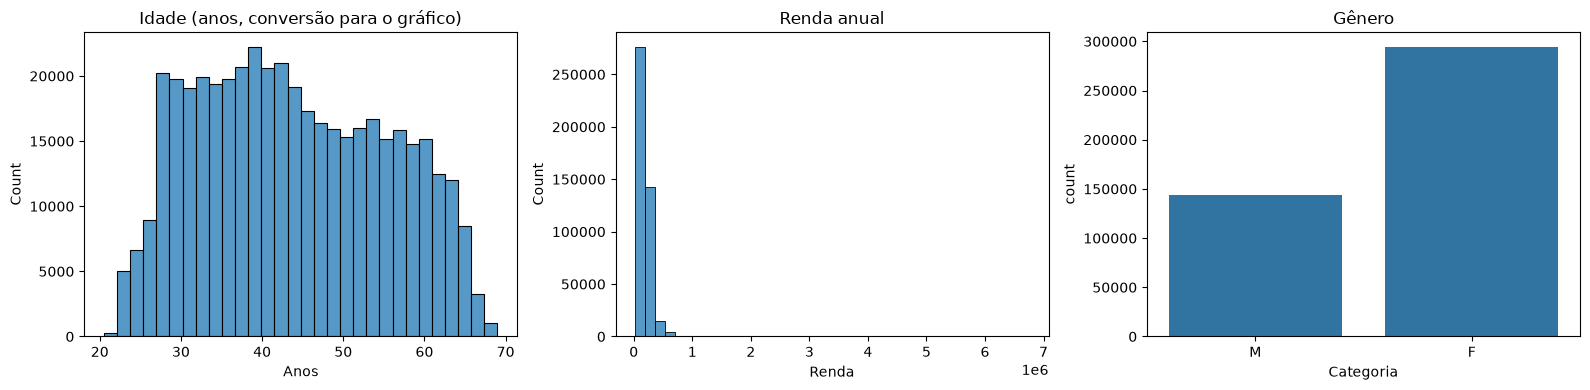

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(np.abs(app_df["IDADE_DIAS"]) / 365.25, bins=30, ax=axes[0])
axes[0].set(title="Idade (anos, conversão para o gráfico)", xlabel="Anos")
sns.histplot(app_df["RENDA_ANUAL"], bins=40, ax=axes[1])
axes[1].set(title="Renda anual", xlabel="Renda")
sns.countplot(data=app_df, x="GENERO", ax=axes[2])
axes[2].set(title="Gênero", xlabel="Categoria")
plt.tight_layout()
fig.savefig(FIGURES / "01_distribuicoes.png", dpi=160, bbox_inches="tight")
plt.show()

**O que observei:** a renda tem alguns valores bem maiores que a maioria, então a média pode não representar tão bem uma pessoa típica. A quantidade por gênero mostra quem está na base, mas não explica por si só quem atrasa pagamentos.

## 3. Relação entre números

Este gráfico compara algumas colunas numéricas. Uma correlação mostra se dois valores costumam variar juntos; ela não prova que um causa o outro.


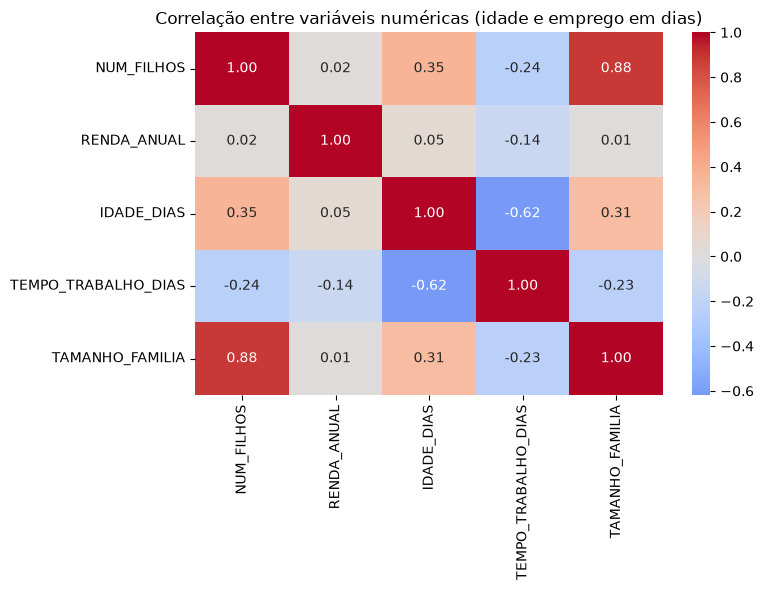

In [31]:
colunas_corr = ["NUM_FILHOS", "RENDA_ANUAL", "IDADE_DIAS", "TEMPO_TRABALHO_DIAS", "TAMANHO_FAMILIA"]
matriz_corr = app_df[colunas_corr].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlação entre variáveis numéricas (idade e emprego em dias)")
fig.tight_layout()
fig.savefig(FIGURES / "02_correlacoes.png", dpi=160, bbox_inches="tight")
plt.show()

**O que observei:** número de filhos e tamanho da família estão bem relacionados (0,88), então podem trazer informações parecidas. Idade e tempo de emprego também variam em sentidos opostos (-0,62). Esses dois campos ainda estão registrados em dias negativos, e o valor especial do tempo de emprego será ajustado no notebook 02.

## 4. Valores muito distantes dos demais


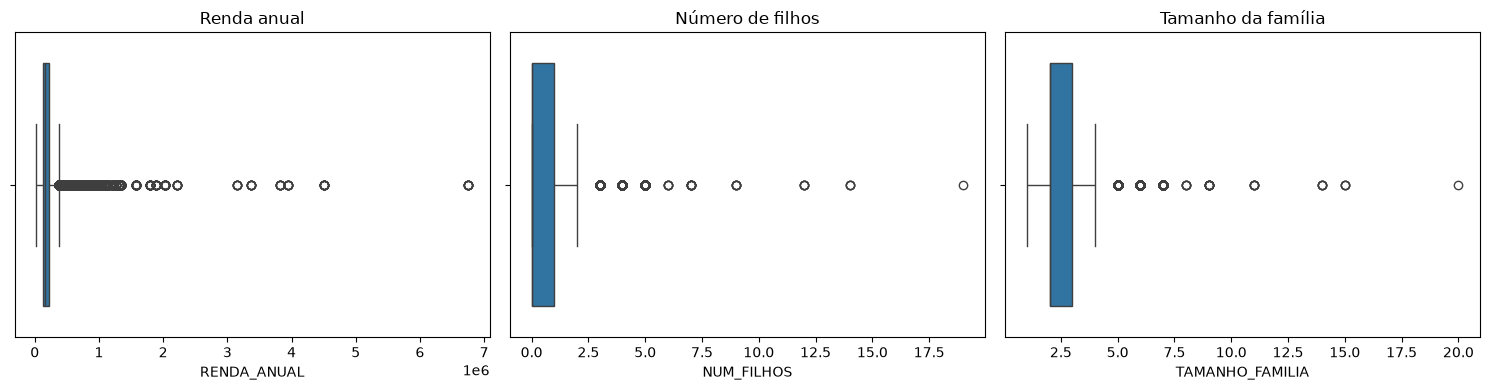

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=app_df["RENDA_ANUAL"], ax=axes[0])
axes[0].set_title("Renda anual")
sns.boxplot(x=app_df["NUM_FILHOS"], ax=axes[1])
axes[1].set_title("Número de filhos")
sns.boxplot(x=app_df["TAMANHO_FAMILIA"], ax=axes[2])
axes[2].set_title("Tamanho da família")
fig.tight_layout()
fig.savefig(FIGURES / "03_valores_extremos.png", dpi=160, bbox_inches="tight")
plt.show()

**O que observei:** a renda anual tem uma cauda longa: metade dos clientes ganha entre 121,5 mil e 225 mil, mas o máximo chega a 6,75 milhões, e cerca de 4% dos cadastros ficam acima do limite superior do boxplot. Em número de filhos e tamanho da família, a maioria está entre 0 e 3, com casos raros de até 19 filhos e 20 membros (26 cadastros com mais de 5 filhos). Esses valores são incomuns, mas plausíveis, então não foram removidos nem cortados. A Árvore de Decisão, modelo escolhido, é pouco sensível a valores extremos, e nos modelos sensíveis à escala o `StandardScaler` é aplicado dentro do pipeline (notebook 03).

## 5. Frequência de clientes com atraso grave

,clientes
TARGET,
0,45318
1,667


,proporcao
MAU_PAGADOR,
0,0.985495
1,0.014505


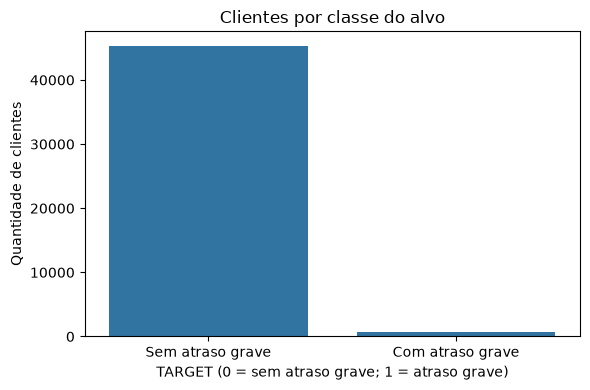

In [33]:
credit_df["MAU_PAGADOR"] = credit_df["STATUS"].isin(["2", "3", "4", "5"])
target_eda = credit_df.groupby("ID")["MAU_PAGADOR"].max().astype(int)
display(target_eda.value_counts().rename_axis(TARGET).to_frame("clientes"))
display(target_eda.value_counts(normalize=True).rename("proporcao").to_frame())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=target_eda, ax=ax)
ax.set_title("Clientes por classe do alvo")
ax.set_xlabel("TARGET (0 = sem atraso grave; 1 = atraso grave)")
ax.set_ylabel("Quantidade de clientes")
ax.set_xticks([0, 1], ["Sem atraso grave", "Com atraso grave"])
fig.tight_layout()
fig.savefig(FIGURES / "04_balanceamento_alvo.png", dpi=160, bbox_inches="tight")
plt.show()

**O que observei:** 667 dos 45.985 clientes (1,45%) tiveram ao menos um atraso de 60 dias ou mais. `TARGET = 0` significa que não foi observado atraso grave, mas ainda pode incluir atrasos menores. Como a classe de atraso grave é bem menor, a acurácia sozinha pode esconder erros; no notebook 03 também comparo o recall dos modelos.

## 6. Resumo da exploração

A base cadastral tem muitas ocupações não informadas e algumas rendas muito altas. `IDADE_DIAS` e `TEMPO_TRABALHO_DIAS` são os campos originais em dias; o último contém o código especial `365243`, que não representa uma duração real. Há 47 IDs repetidos no cadastro, removidos no notebook 02. Os clientes com atraso grave são poucos em relação ao total, então essa diferença será considerada ao comparar os modelos.